<a href="https://colab.research.google.com/github/kjs444642-alt/deep-learning-project/blob/main/%EC%A4%91%EA%B0%84%EB%B3%B4%EA%B3%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1주차: 데이터 준비 및 환경 구축

1주차에는 프로젝트에 사용할 콘크리트 균열 이미지 데이터셋을 준비하고, 딥러닝 학습을 위한 환경을 구축하였다.

우선 Kaggle에서 제공하는 Concrete Crack Images for Classification 데이터셋을 다운로드하고, Positive(균열 있음)와 Negative(균열 없음) 폴더 구조를 확인하였다. 이후 각 클래스별 이미지 개수를 확인하여 데이터가 균형적으로 구성되어 있음을 파악하였다.

또한 샘플 이미지를 출력하여 균열의 형태와 특징을 시각적으로 분석하였으며, 이미지 크기가 227×227로 일정하게 구성되어 있음을 확인하였다. 이를 통해 CNN 기반 이미지 분류 모델 학습에 적합한 데이터셋임을 확인하였다.

마지막으로 프로젝트 전체 구조를 설계하고, Conv2D를 이용한 특징 추출, MaxPooling을 통한 차원 축소, Dense Layer를 이용한 최종 분류 구조 등 CNN 모델의 기본 아키텍처 초안을 구성하였다.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [3]:
import os
os.listdir('/content/')

['.config', 'Positive', 'Negative', 'archive.zip', 'sample_data']

In [4]:
import os

positive_dir = '/content/Positive'
negative_dir = '/content/Negative'

print("Positive 개수:", len(os.listdir(positive_dir)))
print("Negative 개수:", len(os.listdir(negative_dir)))

Positive 개수: 20000
Negative 개수: 20000


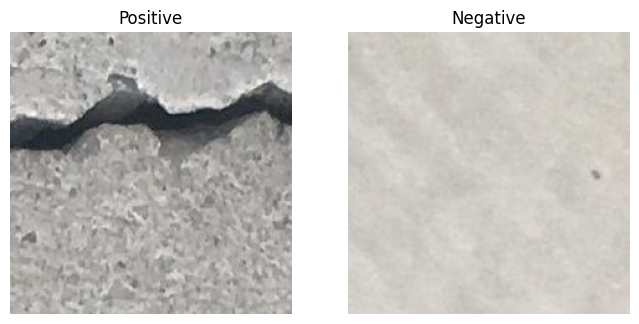

In [5]:
import matplotlib.pyplot as plt
import random
from PIL import Image

sample_pos = random.choice(os.listdir(positive_dir))
sample_neg = random.choice(os.listdir(negative_dir))

img1 = Image.open(os.path.join(positive_dir, sample_pos))
img2 = Image.open(os.path.join(negative_dir, sample_neg))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Positive")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Negative")
plt.axis('off')

plt.show()

In [6]:
sample_img = Image.open(os.path.join(positive_dir, os.listdir(positive_dir)[0]))
print(sample_img.size) #이미지 사이즈

(227, 227)


#일정 계획
### 1주차: 데이터 준비 및 환경 구축
* 데이터 구조 파악 (Positive / Negative 분류)
* 샘플 이미지 확인 및 데이터 크기 분석
* 프로젝트 전체 설계 및 모델 구조 초안 작성
### 2주차: 데이터 전처리 및 모델 설계
* 이미지 크기 통일 및 정규화 수행
* 데이터 증강(Data Augmentation) 적용 (회전, 좌우 반전, 밝기 변화 등)
* CNN 모델 구조 설계 (Conv2D, MaxPooling, BatchNorm, Dense Layer 구성)
* 학습 / 검증 데이터 분할
### 3주차: 모델 학습 및 성능 평가
* CNN 모델 학습 진행
* 손실 함수 및 정확도 변화 확인
* 과적합 방지를 위한 하이퍼파라미터 조정 (learning rate, batch size 등)
* 데이터 증강 효과 비교 분석
* 모델 성능 평가 (Accuracy, Loss)
### 4주차: 성능 개선 및 결과 정리
* 모델 구조 개선 및 추가 실험
* 성능 최적화 (정규화, Dropout 등 적용 가능)
* 최종 모델 선정
* 결과 시각화 (그래프, 샘플 예측 결과)
* 프로젝트 보고서 및 발표 자료 작성

In [7]:
# =========================
# 이미지 크기 통일 및 정규화
# =========================

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),   # 이미지 크기 통일
    transforms.ToTensor(),           # 텐서 변환
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],        # 정규화
        std=[0.5, 0.5, 0.5]
    )
])

print("이미지 전처리 및 정규화 완료")

이미지 전처리 및 정규화 완료


In [8]:
# =========================
# 데이터 증강 (Data Augmentation)
# =========================

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),          # 이미지 크기 통일

    transforms.RandomHorizontalFlip(),      # 좌우 반전

    transforms.RandomRotation(10),          # 이미지 회전

    transforms.ColorJitter(
        brightness=0.2                      # 밝기 변화
    ),

    transforms.ToTensor(),                  # 텐서 변환

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("데이터 증강 적용 완료")

데이터 증강 적용 완료


In [9]:
# =========================
# CNN 모델 구조 설계
# =========================

import torch
import torch.nn as nn

class BetterCNN(nn.Module):
    def __init__(self):
        super(BetterCNN, self).__init__()

        # 특징 추출 부분
        self.features = nn.Sequential(

            # Conv Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 분류 부분 (Dense Layer)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 모델 생성
model = BetterCNN()

print(model)

BetterCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=2

In [13]:
import os
os.listdir('/content/')

['.config', 'Positive', 'Negative', 'archive.zip', 'sample_data']

In [17]:
import os
import shutil

# 새 폴더 생성
os.makedirs('/content/crack_dataset', exist_ok=True)

# Positive / Negative 이동
shutil.move('/content/Positive', '/content/crack_dataset/Positive')
shutil.move('/content/Negative', '/content/crack_dataset/Negative')

print("폴더 정리 완료")

폴더 정리 완료


In [18]:
# =========================
# 데이터셋 불러오기 및 분할
# =========================

from torchvision import datasets
from torch.utils.data import random_split, DataLoader

dataset = datasets.ImageFolder(
    root='/content/crack_dataset',
    transform=transform
)

# 학습 80% / 검증 20%
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("전체 데이터 개수:", len(dataset))
print("학습 데이터 개수:", len(train_dataset))
print("검증 데이터 개수:", len(val_dataset))

print("클래스:", dataset.classes)

전체 데이터 개수: 40000
학습 데이터 개수: 32000
검증 데이터 개수: 8000
클래스: ['Negative', 'Positive']
